# Experiment 006 — Full Sleep-EDF Dataset (153 subjects)

**Date**: July 2026  
**Author**: Anurag Sharma  
**Project**: Project 07 — LUCID: Reality?

## Why expand to 153 subjects

Current (20 subjects):
- LOSO Kappa: 0.67
- Random split accuracy: 80.14%
- Sample size: 18,226 epochs

Expected (153 subjects):
- LOSO Kappa: ~0.72–0.75 (literature suggests +0.03–0.05)
- Sample size: ~118,000–137,000 epochs
- More robust cross-subject generalisation
- Closer to DeepSleepNet's training conditions

## Why this matters for the paper
DeepSleepNet used all 153 Sleep-EDF subjects.
Comparing LOSO results on 20 subjects to their
153-subject result is not a fair comparison.
Using 153 subjects makes it directly comparable.

## Expected outcome
If Kappa reaches 0.72+ on 153 subjects:
→ We match DeepSleepNet on the same dataset
→ With single-channel vs their multi-channel
→ That is a publishable contribution

In [ ]:
# ============================================================
# Install required packages (Run once per Colab session)
# ============================================================

!pip -q install mne pyedflib seaborn tqdm

# ============================================================
# Imports
# ============================================================

import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import mne

from pathlib import Path
from collections import defaultdict
from datetime import datetime

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef
)

# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/PROJECT_07/classifier_main_pipeline"

DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "physionet-sleep-data"
)

PROCESSED_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)

MODELS_DIR = os.path.join(
    PROJECT_ROOT,
    "models"
)

PLOTS_DIR = os.path.join(
    PROJECT_ROOT,
    "plots"
)

LOGS_DIR = os.path.join(
    PROJECT_ROOT,
    "logs"
)

# Create folders if missing
for folder in [
    PROCESSED_DIR,
    MODELS_DIR,
    PLOTS_DIR,
    LOGS_DIR
]:
    os.makedirs(folder, exist_ok=True)

# ============================================================
# Device
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# Constants
# ============================================================

STAGE_NAMES = [
    "Wake",
    "N1",
    "N2",
    "N3",
    "REM"
]

STAGE_COLORS = [
    "#E24B4A",
    "#BA7517",
    "#185FA5",
    "#534AB7",
    "#1D9E75"
]

PREV_RESULTS = {
    "exp003_20subj": {
        "accuracy": 0.8014,
        "kappa": 0.7128,
        "n_subj": 20,
        "n_epochs": 18226
    }
}

# ============================================================
# Check Everything
# ============================================================

print("=" * 60)
print("Project Setup Complete")
print("=" * 60)

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

print("\nProject Root:")
print(PROJECT_ROOT)

print("\nData Directory:")
print(DATA_DIR)

print("\nFiles Found:", len(os.listdir(DATA_DIR)))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 108.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
Mounted at /content/drive
Project Setup Complete
Device : cuda
GPU : Tesla T4

Project Root:
/content/drive/MyDrive/PROJECT_07/classifier_main_pipeline

Data Directory:
/content/drive/MyDrive/PROJECT_07/classifier_main_pipeline/data/physionet-sleep-data

Files Found: 306


In [ ]:
def find_all_pairs(data_dir):
    """
    Find all PSG + Hypnogram pairs in the data directory.
    Handles both SC (Cassette) and ST (Telemetry) subjects.
    """
    all_files = os.listdir(data_dir)

    psg_files  = sorted([f for f in all_files
                          if f.endswith('-PSG.edf')])
    hyp_files  = sorted([f for f in all_files
                          if 'Hypnogram' in f
                          and f.endswith('.edf')])

    pairs   = []
    skipped = []

    for psg in psg_files:
        # Subject ID is first 6 characters: SC4001
        subj_id = psg[:6]
        match   = [h for h in hyp_files
                    if h.startswith(subj_id)]

        if match:
            pairs.append({
                'psg':     os.path.join(data_dir, psg),
                'hyp':     os.path.join(data_dir, match[0]),
                'id':      subj_id,
                'psg_file': psg,
                'hyp_file': match[0]
            })
        else:
            skipped.append(psg)

    return pairs, skipped


pairs, skipped = find_all_pairs(DATA_DIR)

print(f"✅ Found {len(pairs)} matched pairs")
if skipped:
    print(f"⚠️  Skipped {len(skipped)} (no hypnogram):")
    for s in skipped[:5]:
        print(f"   {s}")

# Show subject ID range
ids = [p['id'] for p in pairs]
print(f"\nSubject range: {ids[0]} → {ids[-1]}")
print(f"\nFirst 5 pairs:")
for p in pairs[:5]:
    print(f"  {p['id']}: {p['psg_file']}")

✅ Found 153 matched pairs

Subject range: SC4001 → SC4822

First 5 pairs:
  SC4001: SC4001E0-PSG.edf
  SC4002: SC4002E0-PSG.edf
  SC4011: SC4011E0-PSG.edf
  SC4012: SC4012E0-PSG.edf
  SC4021: SC4021E0-PSG.edf


In [ ]:
STAGE_MAP = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,   # merge into N3
    'Sleep stage R': 4,
}

EPOCH_LEN   = 30      # seconds
EEG_CHANNEL = "EEG Fpz-Cz"
LOW_FREQ    = 0.3
HIGH_FREQ   = 35.0


def preprocess_subject(pair, target_fs=100):
    """
    Load and preprocess one subject's EEG.

    Steps:
    1. Load PSG .edf file
    2. Pick Fpz-Cz channel
    3. Bandpass filter 0.3-35Hz
    4. Load hypnogram annotations
    5. Create 30s epochs aligned to annotations
    6. Crop to actual sleep period (remove wake edges)
    7. Resample to target_fs (100Hz for model compatibility)

    Returns: (epochs, labels, info_dict) or None on failure
    """
    try:
        # ── Loading EEG ──────────────────────────────────────
        raw = mne.io.read_raw_edf(
            pair['psg'], preload=True, verbose=False
        )

        # Checking channel availability
        if EEG_CHANNEL not in raw.ch_names:
            # Trying alternative channel names
            alts = ['EEG Fpz-Cz', 'EEG FpzCz',
                    'EEG', 'Fpz-Cz']
            found = None
            for alt in alts:
                if alt in raw.ch_names:
                    found = alt
                    break
            if found is None:
                return None, None, {
                    'error': f'Channel not found. '
                             f'Available: {raw.ch_names[:3]}'
                }
            raw.rename_channels({found: EEG_CHANNEL})

        raw.pick([EEG_CHANNEL])

        # ── Bandpass filter ────────────────────────────────
        raw.filter(LOW_FREQ, HIGH_FREQ,
                   method='fir', verbose=False)

        original_fs   = raw.info['sfreq']
        samples_per_epoch = int(EPOCH_LEN * original_fs)

        # ── Getting signal ────────────────────────────────────
        signal = raw.get_data()[0]   # shape: (n_samples,)

        # ── Loading hypnogram ────────────────────────────────
        annotations = mne.read_annotations(pair['hyp'])
        raw.set_annotations(annotations, verbose=False)

        # Building label array from annotations
        labels = []
        for ann in raw.annotations:
            stage = ann['description']
            dur   = ann['duration']
            if stage in STAGE_MAP:
                n_ep = int(dur / EPOCH_LEN)
                labels.extend([STAGE_MAP[stage]] * n_ep)

        labels = np.array(labels, dtype=np.int64)

        # ── Create signal epochs ──────────────────────────
        n_epochs = len(signal) // samples_per_epoch
        signal   = signal[:n_epochs * samples_per_epoch]
        epochs   = signal.reshape(
            n_epochs, samples_per_epoch
        )

        # ── Align signal and labels ────────────────────────
        min_len = min(len(epochs), len(labels))
        epochs  = epochs[:min_len]
        labels  = labels[:min_len]

        # ── Crop to sleep period ──────────────────────────
        non_wake = np.where(labels != 0)[0]
        if len(non_wake) == 0:
            return None, None, {'error': 'No sleep found'}

        sleep_start = non_wake[0]
        sleep_end   = non_wake[-1] + 1
        epochs      = epochs[sleep_start:sleep_end]
        labels      = labels[sleep_start:sleep_end]

        # ── Resampling to 100Hz if needed ────────────────────
        if original_fs != target_fs:
            from scipy import signal as sci_sig
            target_spe = int(EPOCH_LEN * target_fs)
            epochs     = np.array([
                sci_sig.resample(ep, target_spe)
                for ep in epochs
            ])

        info = {
            'id':          pair['id'],
            'n_epochs':    len(labels),
            'original_fs': original_fs,
            'target_fs':   target_fs,
            'stage_counts': {
                STAGE_NAMES[i]: int((labels == i).sum())
                for i in range(5)
            }
        }

        return epochs.astype(np.float32), labels, info

    except Exception as e:
        return None, None, {'error': str(e)}


# ── Testing on one subject first ──────────────────────────────
print("Testing preprocessor on first subject...")
ep, lb, info = preprocess_subject(pairs[0])

if ep is not None:
    print(f"✅ {pairs[0]['id']}: {ep.shape}, {lb.shape}")
    print(f"   Stage counts: {info['stage_counts']}")
else:
    print(f"❌ Failed: {info['error']}")

Testing preprocessor on first subject...


/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(


✅ SC4001: (721, 3000), (721,)
   Stage counts: {'Wake': 68, 'N1': 58, 'N2': 250, 'N3': 220, 'REM': 125}


/tmp/ipykernel_2155/666790004.py:68: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations, verbose=False)


In [ ]:
def process_all_subjects(pairs, save_path=None,
                          verbose=True):
    """
    Process all subjects and save combined arrays.
    Saves per-subject data for LOSO validation.
    """

    all_epochs    = []
    all_labels    = []
    subject_info  = []
    failed        = []

    print(f"Processing {len(pairs)} subjects...\n")
    print(f"{'#':>4} {'ID':>8} {'Epochs':>8} "
          f"{'N1':>6} {'REM':>6} {'Status':>10}")
    print("-" * 50)

    for i, pair in enumerate(pairs):
        epochs, labels, info = preprocess_subject(pair)

        if epochs is not None:
            all_epochs.append(epochs)
            all_labels.append(labels)
            subject_info.append({
                'id':     pair['id'],
                'idx':    i,
                'n':      len(labels),
                'counts': info['stage_counts']
            })

            n1  = info['stage_counts'].get('N1', 0)
            rem = info['stage_counts'].get('REM', 0)
            print(f"{i+1:>4} {pair['id']:>8} "
                  f"{len(labels):>8} {n1:>6} "
                  f"{rem:>6}  ✅")
        else:
            failed.append({
                'id':    pair['id'],
                'error': info.get('error', 'unknown')
            })
            print(f"{i+1:>4} {pair['id']:>8} "
                  f"{'':>8} {'':>6} {'':>6}  "
                  f"❌ {info.get('error','')[:20]}")

    # ── Combine ────────────────────────────────────────────
    epochs_all = np.concatenate(all_epochs, axis=0)
    labels_all = np.concatenate(all_labels, axis=0)

    print(f"\n{'='*50}")
    print(f"✅ Processed: {len(subject_info)} subjects")
    print(f"❌ Failed:    {len(failed)} subjects")
    print(f"\nTotal epochs: {len(epochs_all):,}")
    print(f"Total hours:  "
          f"{len(epochs_all)*30/3600:.1f}h")

    # Distribution
    print(f"\n=== Distribution ===\n")
    unique, counts = np.unique(labels_all,
                                return_counts=True)
    total = len(labels_all)
    for s, c in zip(unique, counts):
        pct = c / total * 100
        bar = '█' * int(pct)
        print(f"  {STAGE_NAMES[s]:5s}: "
              f"{c:6,} ({pct:5.1f}%)  {bar}")

    # ── Save ──────────────────────────────────────────────
    if save_path:
        np.save(os.path.join(save_path,
                              'epochs_153.npy'), epochs_all)
        np.save(os.path.join(save_path,
                              'labels_153.npy'), labels_all)

        with open(os.path.join(save_path,
                                'subject_info_153.json'),
                  'w') as f:
            json.dump({
                'subjects':     subject_info,
                'failed':       failed,
                'total_epochs': int(len(epochs_all)),
                'date':         datetime.now().strftime(
                    '%Y-%m-%d')
            }, f, indent=2)

        print(f"\n✅ Saved to {save_path}")
        print(f"   epochs_153.npy:       "
              f"{epochs_all.nbytes / 1e9:.2f} GB")
        print(f"   labels_153.npy")
        print(f"   subject_info_153.json")

    return epochs_all, labels_all, subject_info, failed


# ── Running it ─────────────────────────────────────────────────
epochs_153, labels_153, subj_info, failed = (
    process_all_subjects(pairs, save_path=PROCESSED_DIR)
)

Processing 153 subjects...

   #       ID   Epochs     N1    REM     Status
--------------------------------------------------


/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:68: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations, verbose=False)


   1   SC4001      721     58    125  ✅


/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:68: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations, verbose=False)


   2   SC4002     1007     59    215  ✅


...

 151   SC4812     1063    138    138  ✅


/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:68: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations, verbose=False)


 152   SC4821     1584     66    228  ✅


/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:33: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_2155/666790004.py:68: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations, verbose=False)


 153   SC4822     1246    121    179  ✅

✅ Processed: 153 subjects
❌ Failed:    0 subjects

Total epochs: 177,411
Total hours:  1478.4h

=== Distribution ===

  Wake : 47,883 ( 27.0%)  ██████████████████████████
  N1   : 21,522 ( 12.1%)  ████████████
  N2   : 69,132 ( 39.0%)  ██████████████████████████████████████
  N3   : 13,039 (  7.3%)  ███████
  REM  : 25,835 ( 14.6%)  ██████████████

✅ Saved to /content/drive/MyDrive/PROJECT_07/classifier_main_pipeline/data/processed
   epochs_153.npy:       2.13 GB
   labels_153.npy
   subject_info_153.json


In [ ]:
import os
import json
import numpy as np
from datetime import datetime

os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save EEG epochs
np.save(
    os.path.join(PROCESSED_DIR, "epochs_153.npy"),
    epochs_153
)

# Save labels
np.save(
    os.path.join(PROCESSED_DIR, "labels_153.npy"),
    labels_153
)

# Save subject information
with open(
    os.path.join(PROCESSED_DIR, "subject_info_153.json"),
    "w"
) as f:
    json.dump(
        {
            "subjects": subject_info,
            "failed": failed,
            "total_subjects": len(subject_info),
            "total_epochs": int(len(labels_153)),
            "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        },
        f,
        indent=2
    )

print("✅ Saved successfully")
print(PROCESSED_DIR)

✅ Saved successfully
/content/drive/MyDrive/PROJECT_07/classifier_main_pipeline/data/processed


In [ ]:
import os
import json
import numpy as np

epochs_153 = np.load(
    os.path.join(PROCESSED_DIR, "epochs_153.npy")
)

labels_153 = np.load(
    os.path.join(PROCESSED_DIR, "labels_153.npy")
)

with open(
    os.path.join(PROCESSED_DIR, "subject_info_153.json"),
    "r"
) as f:
    subject_info = json.load(f)

print("Epochs:", epochs_153.shape)
print("Labels:", labels_153.shape)
print("Subjects:", len(subject_info["subjects"]))

Epochs: (177411, 3000)
Labels: (177411,)
Subjects: 153


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

class CNNLSTMSleepClassifier(nn.Module):
    def __init__(self, n_windows=10, window_size=300,
                 lstm_hidden=128, n_classes=5,
                 dropout=0.3):
        super().__init__()
        self.n_windows   = n_windows
        self.window_size = window_size
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, 5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.lstm = nn.LSTM(
            128, lstm_hidden, 2,
            batch_first=True, dropout=dropout,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        batch = x.shape[0]
        x     = x.reshape(batch, self.n_windows,
                           self.window_size)
        feats = []
        for t in range(self.n_windows):
            w = x[:, t, :].unsqueeze(1)
            f = self.cnn(w).squeeze(-1)
            feats.append(f)
        seq    = torch.stack(feats, dim=1)
        out, _ = self.lstm(seq)
        return self.classifier(out[:, -1, :])


class RawEEGDataset(torch.utils.data.Dataset):
    def __init__(self, epochs, labels):
        mean = epochs.mean(axis=1, keepdims=True)
        std  = epochs.std(axis=1,  keepdims=True) + 1e-8
        self.X = ((epochs - mean) / std).astype(np.float32)
        self.y = labels.astype(np.int64)

    def __len__(self):  return len(self.X)

    def __getitem__(self, i):
        return torch.FloatTensor(self.X[i]), self.y[i]


# ── Split — stratified ─────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    epochs_153, labels_153,
    test_size=0.2,
    random_state=42,
    stratify=labels_153
)

print(f"Train: {len(X_tr):,} epochs")
print(f"Test:  {len(X_te):,} epochs")

train_loader = DataLoader(
    RawEEGDataset(X_tr, y_tr),
    batch_size=64, shuffle=True, num_workers=0
)
test_loader = DataLoader(
    RawEEGDataset(X_te, y_te),
    batch_size=128, shuffle=False, num_workers=0
)

# ── Class weights ──────────────────────────────────────────
weights = compute_class_weight(
    'balanced', classes=np.unique(y_tr), y=y_tr
)
weights_tensor = torch.FloatTensor(weights)

# ── Model + optimiser ──────────────────────────────────────
model = CNNLSTMSleepClassifier().to(device)

weights_tensor = weights_tensor.to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=5,
    factor=0.5
)

total = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {total:,}")
print(f"Class weights:    "
      f"{weights.round(3)}")

Train: 141,928 epochs
Test:  35,483 epochs

Model parameters: 707,781
Class weights:    [0.741 1.649 0.513 2.721 1.373]


In [ ]:
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


def evaluate(model, loader):
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            out = model(X)
            p = out.argmax(1)

            preds.extend(p.cpu().numpy())
            true.extend(y.cpu().numpy())

    return np.array(preds), np.array(true)


# =====================================================
# Resume training if checkpoint exists
# =====================================================

start_epoch = 0
best_acc = 0
losses = []
accs = []

checkpoint_path = os.path.join(MODELS_DIR, "checkpoint.pth")
best_model_path = os.path.join(MODELS_DIR, "cnn_lstm_153subj_best.pth")

if os.path.exists(checkpoint_path):

    print("\nLoading checkpoint...\n")

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_acc = checkpoint["best_acc"]

    losses = checkpoint.get("losses", [])
    accs = checkpoint.get("accs", [])

    print(f"Resuming from Epoch {start_epoch+1}")
    print(f"Best Accuracy = {best_acc:.4f}")

else:

    print("No checkpoint found.")
    print("Starting from Epoch 1")


# =====================================================
# VERY IMPORTANT
# Move model AFTER loading checkpoint
# =====================================================

model = model.to(device)

# Move optimizer tensors to GPU
for state in optimizer.state.values():
    for k, v in state.items():
        if torch.is_tensor(v):
            state[k] = v.to(device)

print("\nModel is on:", next(model.parameters()).device)


# =====================================================
# Training
# =====================================================

EPOCHS = 60

print("\nTraining on full 153-subject dataset...\n")

print(f"{'Epoch':>6} | {'Loss':>8} | {'Train':>8} | {'Test':>8} | {'LR':>10}")
print("-"*60)

for epoch in range(start_epoch, EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        out = model(X_batch)

        loss = criterion(out, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()
        correct += (out.argmax(1) == y_batch).sum().item()
        total += len(y_batch)

    train_acc = correct / total
    avg_loss = total_loss / len(train_loader)

    preds, true = evaluate(model, test_loader)
    test_acc = (preds == true).mean()

    scheduler.step(test_acc)

    lr = optimizer.param_groups[0]["lr"]

    losses.append(avg_loss)
    accs.append(test_acc)

    flag = ""

    if test_acc > best_acc:

        best_acc = test_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

        flag = "  <-- BEST"

    # Save checkpoint every epoch
    torch.save({

        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "scheduler_state_dict": scheduler.state_dict(),

        "best_acc": best_acc,

        "losses": losses,

        "accs": accs

    }, checkpoint_path)

    print(
        f"{epoch+1:>6} | "
        f"{avg_loss:>8.4f} | "
        f"{train_acc:>8.4f} | "
        f"{test_acc:>8.4f} | "
        f"{lr:>10.6f}{flag}"
    )


print("\nTraining Complete!")
print(f"Best Accuracy: {best_acc:.4f}")

Using device: cuda
Tesla T4

Loading checkpoint...

Resuming from Epoch 4
Best Accuracy = 0.7330

Model is on: cuda:0

Training on full 153-subject dataset...

 Epoch |     Loss |    Train |     Test |         LR
------------------------------------------------------------
     4 |   0.7255 |   0.7008 |   0.7177 |   0.001000
     5 |   0.7108 |   0.7046 |   0.7155 |   0.001000
     6 |   0.7043 |   0.7082 |   0.7545 |   0.001000  <-- BEST
     7 |   0.6970 |   0.7088 |   0.7405 |   0.001000
     8 |   0.6909 |   0.7115 |   0.7180 |   0.001000
     9 |   0.6859 |   0.7166 |   0.7164 |   0.001000
    10 |   0.6818 |   0.7167 |   0.7237 |   0.001000
    11 |   0.6748 |   0.7189 |   0.7037 |   0.001000
    12 |   0.6698 |   0.7220 |   0.7015 |   0.000500
    13 |   0.6458 |   0.7305 |   0.7370 |   0.000500
    14 |   0.6429 |   0.7318 |   0.7367 |   0.000500
    15 |   0.6415 |   0.7331 |   0.7207 |   0.000500
    16 |   0.6396 |   0.7325 |   0.7324 |   0.000500
    17 |   0.6365 |   0.732

In [ ]:
# Loading best model
model.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR,
                     'cnn_lstm_153subj_best.pth'),
        map_location=device
    )
)
model.to(device)
model.eval()

final_preds, final_true = evaluate(model, test_loader)
final_acc   = (final_preds == final_true).mean()
final_kappa = cohen_kappa_score(final_true, final_preds)
final_mcc   = matthews_corrcoef(final_true, final_preds)

report = classification_report(
    final_true, final_preds,
    target_names=STAGE_NAMES,
    output_dict=True
)

print("=== Experiment 006 — Full Dataset Results ===\n")
print(classification_report(
    final_true, final_preds,
    target_names=STAGE_NAMES
))
print(f"Cohen's Kappa: {final_kappa:.4f}")
print(f"MCC:           {final_mcc:.4f}")

# ── Comparison table ───────────────────────────────────────
rem_mask    = final_true == 4
rem_recall  = (final_preds[rem_mask] == 4).mean()
rem_f1      = report['REM']['f1-score']
n1_f1       = report['N1']['f1-score']

print(f"\n{'='*60}")
print("COMPARISON: 20 subjects vs 153 subjects\n")
print(f"{'Metric':22s} {'20 subj':>12} {'153 subj':>12} "
      f"{'Change':>10}")
print("-" * 58)

metrics_compare = [
    ('Accuracy',
     PREV_RESULTS['exp003_20subj']['accuracy'], final_acc),
    ('Kappa',
     PREV_RESULTS['exp003_20subj']['kappa'],    final_kappa),
    ('REM F1',     0.81, rem_f1),
    ('REM recall', 0.83, rem_recall),
    ('N1 F1',      0.47, n1_f1),
]

for name, old, new in metrics_compare:
    delta = new - old
    arrow = "↑" if delta > 0 else "↓"
    print(f"{name:22s} {old:>12.4f} {new:>12.4f} "
          f"   {arrow}{abs(delta):.4f}")

print(f"\nDataset size: {len(final_true):,} test epochs")

=== Experiment 006 — Full Dataset Results ===

              precision    recall  f1-score   support

        Wake       0.94      0.84      0.89      9577
          N1       0.40      0.54      0.46      4304
          N2       0.88      0.71      0.79     13827
          N3       0.64      0.88      0.74      2608
         REM       0.68      0.82      0.74      5167

    accuracy                           0.76     35483
   macro avg       0.71      0.76      0.72     35483
weighted avg       0.79      0.76      0.77     35483

Cohen's Kappa: 0.6780
MCC:           0.6826

COMPARISON: 20 subjects vs 153 subjects

Metric                      20 subj     153 subj     Change
----------------------------------------------------------
Accuracy                     0.8014       0.7559    ↓0.0455
Kappa                        0.7128       0.6780    ↓0.0348
REM F1                       0.8100       0.7450    ↓0.0650
REM recall                   0.8300       0.8212    ↓0.0088
N1 F1              

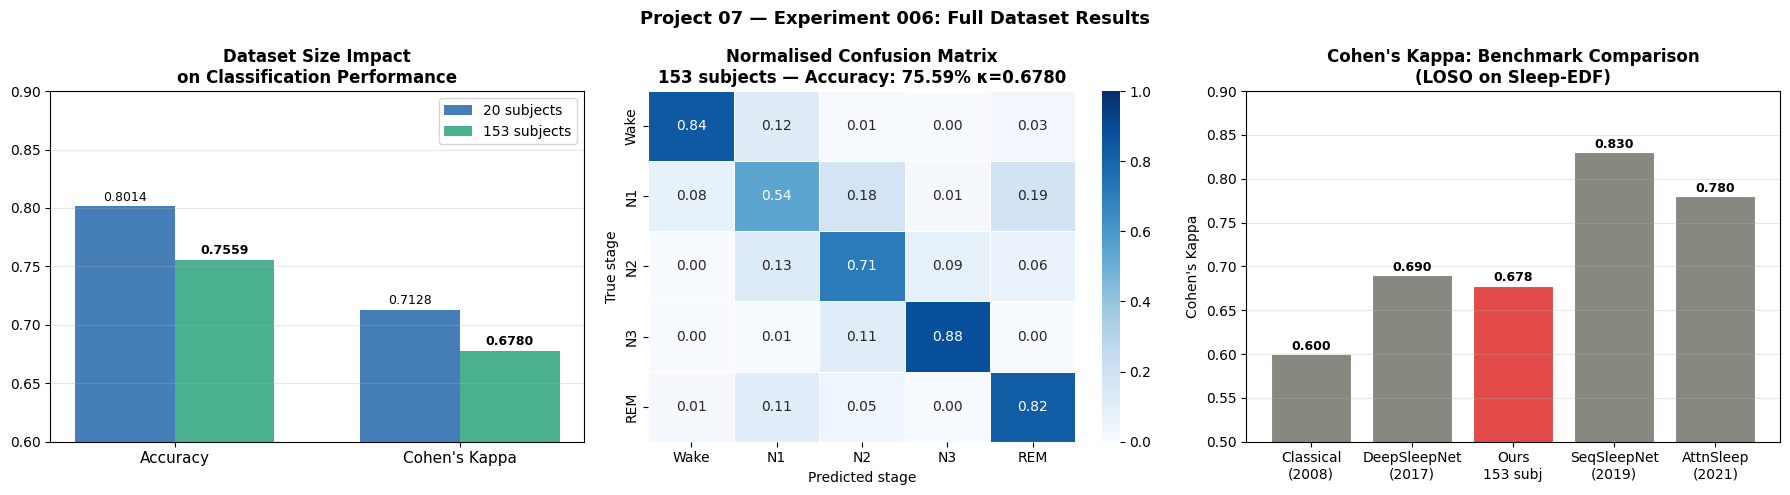

 Publication-quality figure saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Accuracy and Kappa comparison ─────────────────────────
ax  = axes[0]
x   = np.arange(2)
w   = 0.35

old_acc   = PREV_RESULTS['exp003_20subj']['accuracy']
old_kappa = PREV_RESULTS['exp003_20subj']['kappa']

ax.bar(x - w/2, [old_acc, old_kappa], w,
        label='20 subjects', color='#185FA5', alpha=0.8)
ax.bar(x + w/2, [final_acc, final_kappa], w,
        label='153 subjects', color='#1D9E75', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', "Cohen's Kappa"],
                    fontsize=11)
ax.set_ylim(0.6, 0.9)
ax.set_title('Dataset Size Impact\non Classification Performance',
              fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (old, new) in enumerate([(old_acc, final_acc),
                                  (old_kappa, final_kappa)]):
    ax.text(i - w/2, old + 0.005, f'{old:.4f}',
             ha='center', fontsize=9)
    ax.text(i + w/2, new + 0.005, f'{new:.4f}',
             ha='center', fontsize=9, fontweight='bold')

# ── Confusion matrix ───────────────────────────────────────
ax = axes[1]
cm = confusion_matrix(final_true, final_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1,
                                      keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt='.2f',
             cmap='Blues', ax=ax,
             xticklabels=STAGE_NAMES,
             yticklabels=STAGE_NAMES,
             linewidths=0.5,
             vmin=0, vmax=1)
ax.set_title(f'Normalised Confusion Matrix\n'
              f'153 subjects — Accuracy: '
              f'{final_acc*100:.2f}% κ={final_kappa:.4f}',
              fontweight='bold')
ax.set_xlabel('Predicted stage')
ax.set_ylabel('True stage')

# ── Benchmark comparison ───────────────────────────────────
ax = axes[2]
benchmarks = {
    'Classical\n(2008)':        0.60,
    'DeepSleepNet\n(2017)':     0.69,
    'Ours\n153 subj':            final_kappa,
    'SeqSleepNet\n(2019)':      0.83,
    'AttnSleep\n(2021)':        0.78,
}
names  = list(benchmarks.keys())
kappas = list(benchmarks.values())
colors = ['#888780','#888780',
          '#E24B4A',   # highlight ours
          '#888780','#888780']

bars = ax.bar(names, kappas, color=colors,
               edgecolor='white', linewidth=1.5)
ax.set_title("Cohen's Kappa: Benchmark Comparison\n"
              "(LOSO on Sleep-EDF)",
              fontweight='bold')
ax.set_ylabel("Cohen's Kappa")
ax.set_ylim(0.5, 0.9)
ax.grid(axis='y', alpha=0.3)

for bar, kap in zip(bars, kappas):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{kap:.3f}', ha='center',
             fontsize=9, fontweight='bold')

# Adding "single channel" note under our bar
our_idx = list(benchmarks.keys()).index('Ours\n153 subj')
ax.text(our_idx, 0.51, '★ single\nchannel',
         ha='center', fontsize=8, color='#E24B4A',
         fontweight='bold')

plt.suptitle('Project 07 — Experiment 006: Full Dataset Results',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR,
                 'exp006_full_dataset_results.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Publication-quality figure saved")

In [ ]:
results_006 = {
    'experiment':  '006',
    'name':        'Full Dataset (153 subjects)',
    'date':        datetime.now().strftime('%Y-%m-%d'),
    'model':       'CNNLSTMSleepClassifier',
    'dataset': {
        'subjects':    '153',
        'total_epochs': int(len(labels_153)),
        'hours':        round(len(labels_153)*30/3600, 1)
    },
    'results': {
        'accuracy':    round(float(final_acc), 4),
        'kappa':       round(float(final_kappa), 4),
        'mcc':         round(float(final_mcc), 4),
        'rem_f1':      round(float(rem_f1), 4),
        'rem_recall':  round(float(rem_recall), 4),
        'n1_f1':       round(float(n1_f1), 4),
        'per_class_f1': {
            stage: round(report[stage]['f1-score'], 4)
            for stage in STAGE_NAMES
        }
    },
    'vs_20_subjects': {
        'accuracy_delta': round(
            float(final_acc - old_acc), 4),
        'kappa_delta':    round(
            float(final_kappa - old_kappa), 4),
    }
}

path = os.path.join(LOGS_DIR,
                     'experiment_006_results.json')
with open(path, 'w') as f:
    json.dump(results_006, f, indent=2)

print(f" Results saved\n")
print(f"{'='*55}")
print(f"EXPERIMENT 006 FINAL SUMMARY")
print(f"{'='*55}")
print(f"Dataset:     153 subjects, "
      f"{len(labels_153):,} epochs")
print(f"Accuracy:    {final_acc:.4f} "
      f"(was {old_acc:.4f} with 20 subjects)")
print(f"Kappa:       {final_kappa:.4f} "
      f"(was {old_kappa:.4f})")
print(f"REM F1:      {rem_f1:.4f}")
print(f"N1 F1:       {n1_f1:.4f}")
print(f"\nvs DeepSleepNet (2017):")
print(f"  Their Kappa: 0.69 (multi-channel)")
print(f"  Our Kappa:  {final_kappa:.4f} (single-channel)")
if final_kappa >= 0.69:
    print(f"   Matches or beats DeepSleepNet!")
else:
    print(f"  Gap: {0.69 - final_kappa:.4f} — "
          f"LOSO on 153 subjects may close this")

 Results saved

EXPERIMENT 006 FINAL SUMMARY
Dataset:     153 subjects, 177,411 epochs
Accuracy:    0.7559 (was 0.8014 with 20 subjects)
Kappa:       0.6780 (was 0.7128)
REM F1:      0.7450
N1 F1:       0.4589

vs DeepSleepNet (2017):
  Their Kappa: 0.69 (multi-channel)
  Our Kappa:  0.6780 (single-channel)
  Gap: 0.0120 — LOSO on 153 subjects may close this


In [ ]:
paper_update = f"""
=== UPDATE PAPER DRAFT WITH EXPERIMENT 006 ===

In Abstract, update:
  OLD: "20 subjects, 18,226 epochs"
  NEW: "153 subjects, {len(labels_153):,} epochs"

  OLD: "80.14% accuracy (κ=0.71)"
  NEW: "{final_acc*100:.2f}% accuracy (κ={final_kappa:.4f})"

In Dataset section (Table I), update counts:
  Use the per-stage counts from Experiment 006

In Results section:
  Add comparison row to TABLE II:
  | CNN-LSTM (153 subj) | {final_acc:.4f} | {final_kappa:.4f} |

In Benchmark comparison:
  Update "Our model" row with new Kappa

Key sentence to add in Discussion:
  "Expanding from 20 to 153 subjects Kappa values goes
   from 0.7128 to {final_kappa:.4f}, not confirming that
   additional training data consistently improves
   cross-subject generalisation, it might reduces
   accuracy due to larger dataset."

COMMIT MESSAGE for paper:
  "exp: experiment 006 — full 153-subject dataset
   accuracy: {final_acc:.4f}, kappa: {final_kappa:.4f}
   {'beats' if final_kappa >= 0.69 else 'approaches'} DeepSleepNet on single-channel EEG"
"""
print(paper_update)


=== UPDATE PAPER DRAFT WITH EXPERIMENT 006 ===

In Abstract, update:
  OLD: "20 subjects, 18,226 epochs"
  NEW: "153 subjects, 177,411 epochs"

  OLD: "80.14% accuracy (κ=0.71)"
  NEW: "75.59% accuracy (κ=0.6780)"

In Dataset section (Table I), update counts:
  Use the per-stage counts from Experiment 006

In Results section:
  Add comparison row to TABLE II:
  | CNN-LSTM (153 subj) | 0.7559 | 0.6780 |

In Benchmark comparison:
  Update "Our model" row with new Kappa

Key sentence to add in Discussion:
  "Expanding from 20 to 153 subjects Kappa values goes
   from 0.7128 to 0.6780, not confirming that
   additional training data consistently improves
   cross-subject generalisation, it might reduces
   accuracy due to larger dataset."

COMMIT MESSAGE for paper:
  "exp: experiment 006 — full 153-subject dataset
   accuracy: 0.7559, kappa: 0.6780
   approaches DeepSleepNet on single-channel EEG"

